<a href="https://colab.research.google.com/github/Ali-Hamza-developer/pytorch/blob/main/06_dataset_and_dataloader.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch `Dataset` & `DataLoader`

**Ali Hamza**
🔗 [LinkedIn](https://www.linkedin.com/in/alihamzastudent/)

---

Every notebook so far has fed the **entire** training set into the model in one shot — `model(X_train_tensor)`. That works fine for 455 rows, but real datasets can have millions of rows that don't fit in memory at once, and training usually works better in small batches anyway rather than one giant pass.

`Dataset` and `DataLoader` are PyTorch's built-in solution to that:
- **`Dataset`** — a standard way to wrap your data so PyTorch knows how many samples exist and how to fetch any single one
- **`DataLoader`** — wraps a `Dataset` and automatically handles **batching**, **shuffling**, and (optionally) **parallel loading** — so you never manually slice `X_train[i:i+32]` yourself

### 🔄 How the pieces fit together

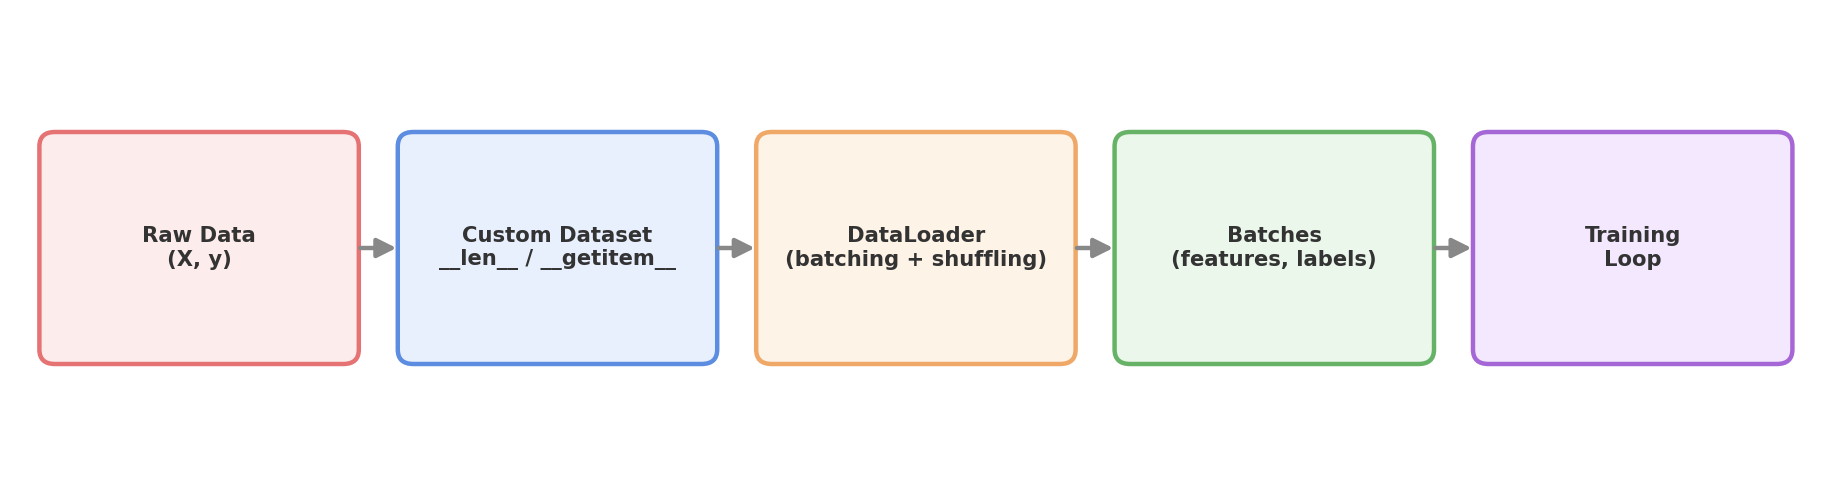

## Step 1 — Create a Small Synthetic Dataset

Instead of loading a real CSV, `sklearn.datasets.make_classification` generates a small fake classification dataset — useful for testing data-pipeline code without waiting on downloads or big files.

In [1]:
from sklearn.datasets import make_classification
import torch

**Parameters explained:**
- `n_samples=10` — only 10 rows, small enough to print and inspect fully
- `n_features=2` — each sample has 2 numeric features (easy to visualize)
- `n_informative=2` — both features actually carry signal about the class (none are noise)
- `n_redundant=0` — no duplicate/derived features
- `n_classes=2` — binary classification, like the breast cancer notebooks
- `random_state=42` — fixes the randomness so the same data is generated every run

In [2]:
# Step 1: Create a synthetic classification dataset using sklearn
X, y = make_classification(
    n_samples=10,      # Number of samples
    n_features=2,      # Number of features
    n_informative=2,   # Number of informative features
    n_redundant=0,     # Number of redundant features
    n_classes=2,        # Number of classes
    random_state=42    # For reproducibility
)

In [3]:
X

array([[ 1.06833894, -0.97007347],
       [-1.14021544, -0.83879234],
       [-2.8953973 ,  1.97686236],
       [-0.72063436, -0.96059253],
       [-1.96287438, -0.99225135],
       [-0.9382051 , -0.54304815],
       [ 1.72725924, -1.18582677],
       [ 1.77736657,  1.51157598],
       [ 1.89969252,  0.83444483],
       [-0.58723065, -1.97171753]])

In [4]:
X.shape

(10, 2)

In [5]:
y

array([1, 0, 0, 0, 0, 1, 1, 1, 1, 0])

In [6]:
y.shape

(10,)

## Step 2 — Convert to PyTorch Tensors

- `dtype=torch.float32` for features — the standard floating-point type `nn.Linear` and most PyTorch layers expect
- `dtype=torch.long` for labels — **classification labels must be `long` (64-bit integers)**, not `float`, because functions like `nn.CrossEntropyLoss` require integer class indices

> ⚠️ **Common mistake:** using `torch.float32` for classification labels instead of `torch.long` — this causes a dtype error the moment the labels are passed into a classification loss function.

In [7]:
# Convert the data to PyTorch tensors
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

In [8]:
X

tensor([[ 1.0683, -0.9701],
        [-1.1402, -0.8388],
        [-2.8954,  1.9769],
        [-0.7206, -0.9606],
        [-1.9629, -0.9923],
        [-0.9382, -0.5430],
        [ 1.7273, -1.1858],
        [ 1.7774,  1.5116],
        [ 1.8997,  0.8344],
        [-0.5872, -1.9717]])

In [9]:
y

tensor([1, 0, 0, 0, 0, 1, 1, 1, 1, 0])

## Step 3 — Building a Custom `Dataset`

Every custom dataset in PyTorch inherits from `torch.utils.data.Dataset` and must implement exactly **two** methods:

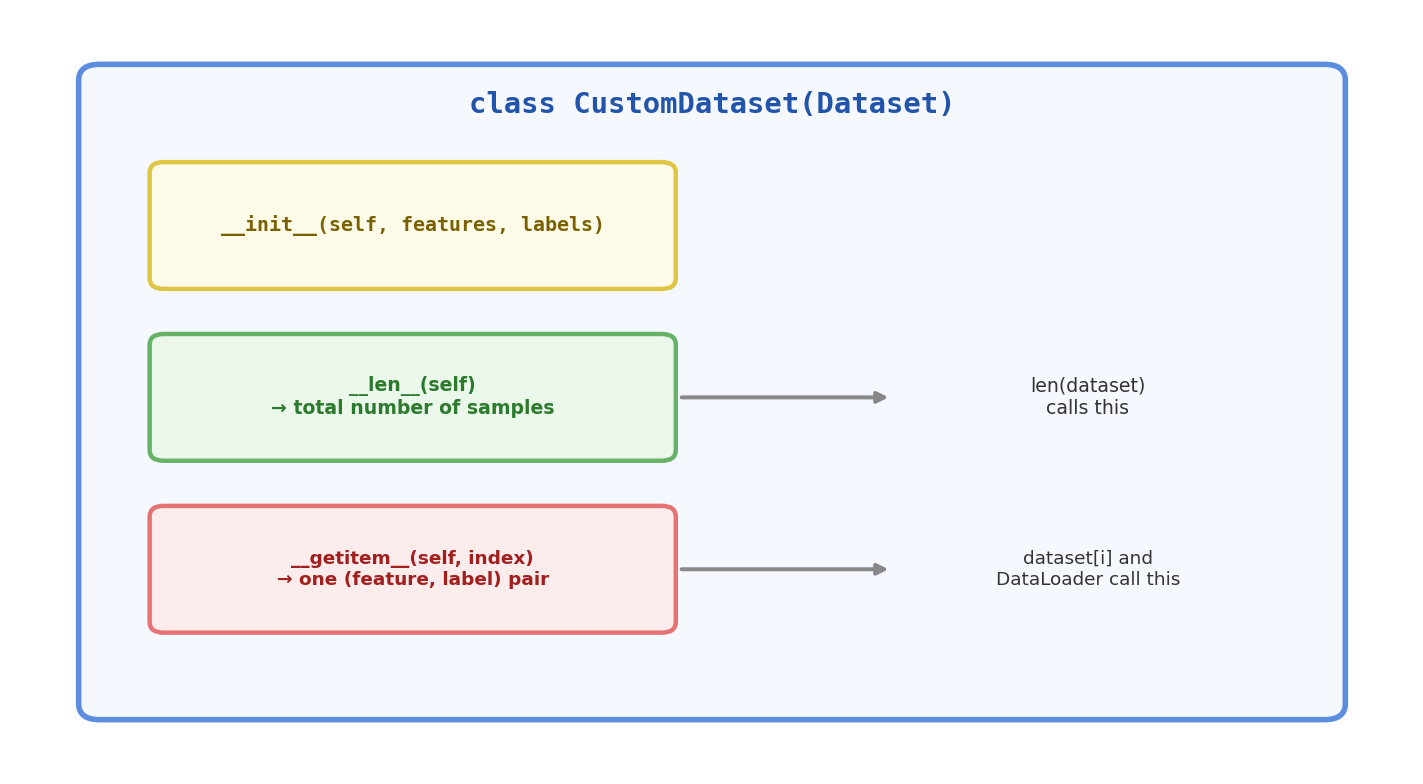

- **`__init__`** — stores whatever data the dataset needs to hold onto (here, the features and labels tensors)
- **`__len__`** — tells PyTorch how many samples exist in total; called automatically whenever you run `len(dataset)`
- **`__getitem__`** — given an index, returns **one** sample as `(features, label)`; this is what both `dataset[i]` and the `DataLoader` call internally, over and over, to build batches

> 💡 Nothing here loads data eagerly into a different format or copies it — `__getitem__` just indexes into the tensors already stored in `__init__`. For huge datasets that don't fit in memory, this is exactly where you'd instead read one file/row from disk on demand.

In [10]:
from torch.utils.data import Dataset, DataLoader

class CustomDataset(Dataset):

  def __init__(self, features, labels):

    self.features = features
    self.labels = labels

  def __len__(self):

    return self.features.shape[0]

  def __getitem__(self, index):

    return self.features[index], self.labels[index]

In [11]:
dataset = CustomDataset(X, y)

### Trying it out

`len(dataset)` calls `__len__` under the hood; `dataset[2]` calls `__getitem__(2)`.

In [12]:
len(dataset)

10

In [13]:
dataset[2]

(tensor([-2.8954,  1.9769]), tensor(0))

## Step 4 — Wrapping it with `DataLoader`

Instead of writing a manual loop that slices `dataset[i:i+batch_size]` and shuffles indices by hand, `DataLoader` does both automatically.

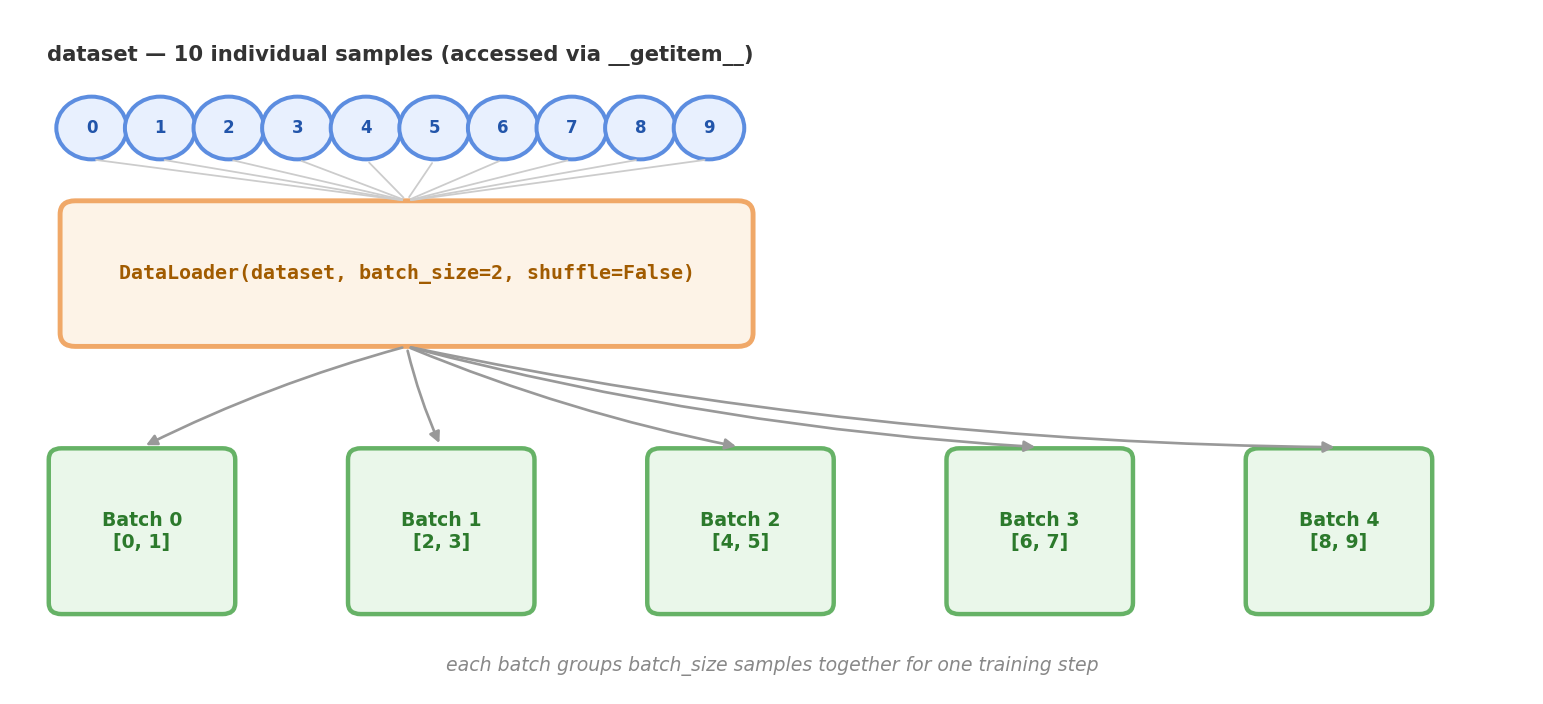

**Key parameters:**
- **`batch_size`** — how many samples get grouped into one batch. Each batch is what a single training step (`model(batch_features)`) sees at once.
- **`shuffle`** — if `True`, the order of samples is randomized every epoch, which helps prevent the model from learning the order data happens to be stored in, rather than the actual patterns
- **`drop_last`** *(not used below, defaults to `False`)* — if the total number of samples doesn't divide evenly by `batch_size`, the last, smaller batch is kept by default; set `drop_last=True` to discard it instead
- **`num_workers`** *(not used below, defaults to `0`)* — how many background processes load data in parallel; useful for large datasets read from disk, unnecessary for small in-memory data like this

In [14]:
dataloader = DataLoader(dataset, batch_size=2, shuffle=False)

In [15]:
for batch_features, batch_labels in dataloader:

  print(batch_features)
  print(batch_labels)
  print("-"*50)

tensor([[ 1.0683, -0.9701],
        [-1.1402, -0.8388]])
tensor([1, 0])
--------------------------------------------------
tensor([[-2.8954,  1.9769],
        [-0.7206, -0.9606]])
tensor([0, 0])
--------------------------------------------------
tensor([[-1.9629, -0.9923],
        [-0.9382, -0.5430]])
tensor([0, 1])
--------------------------------------------------
tensor([[ 1.7273, -1.1858],
        [ 1.7774,  1.5116]])
tensor([1, 1])
--------------------------------------------------
tensor([[ 1.8997,  0.8344],
        [-0.5872, -1.9717]])
tensor([1, 0])
--------------------------------------------------


### Same data, `shuffle=True`

Run this a couple of times — the batch contents stay grouped in twos, but *which* samples end up together, and in what order, changes each run.

In [16]:
shuffled_loader = DataLoader(dataset, batch_size=2, shuffle=True)

for batch_features, batch_labels in shuffled_loader:

  print(batch_features)
  print(batch_labels)
  print("-"*50)

tensor([[ 1.7774,  1.5116],
        [ 1.0683, -0.9701]])
tensor([1, 1])
--------------------------------------------------
tensor([[-1.9629, -0.9923],
        [-0.7206, -0.9606]])
tensor([0, 0])
--------------------------------------------------
tensor([[-0.5872, -1.9717],
        [-2.8954,  1.9769]])
tensor([0, 0])
--------------------------------------------------
tensor([[ 1.8997,  0.8344],
        [ 1.7273, -1.1858]])
tensor([1, 1])
--------------------------------------------------
tensor([[-1.1402, -0.8388],
        [-0.9382, -0.5430]])
tensor([0, 1])
--------------------------------------------------


### A different `batch_size`

With 10 samples and `batch_size=3`, the samples don't divide evenly — the last batch only has 1 sample (`10 = 3+3+3+1`) instead of erroring out.

In [17]:
loader_batch3 = DataLoader(dataset, batch_size=3, shuffle=False)

for i, (batch_features, batch_labels) in enumerate(loader_batch3):
  print(f"Batch {i}: {batch_features.shape[0]} samples")
  print(batch_features)
  print(batch_labels)
  print("-"*50)

Batch 0: 3 samples
tensor([[ 1.0683, -0.9701],
        [-1.1402, -0.8388],
        [-2.8954,  1.9769]])
tensor([1, 0, 0])
--------------------------------------------------
Batch 1: 3 samples
tensor([[-0.7206, -0.9606],
        [-1.9629, -0.9923],
        [-0.9382, -0.5430]])
tensor([0, 0, 1])
--------------------------------------------------
Batch 2: 3 samples
tensor([[ 1.7273, -1.1858],
        [ 1.7774,  1.5116],
        [ 1.8997,  0.8344]])
tensor([1, 1, 1])
--------------------------------------------------
Batch 3: 1 samples
tensor([[-0.5872, -1.9717]])
tensor([0])
--------------------------------------------------


## Step 5 — Why This Replaces Manual Batching

In the earlier training-pipeline notebooks, the entire training set was passed to the model in one call: `model(X_train_tensor)`. That's called **full-batch** training. With `Dataset` + `DataLoader`, the same training loop becomes **mini-batch** training — the outer `for epoch in range(epochs)` loop now wraps an *inner* loop over the dataloader:

```python
for epoch in range(epochs):
    for batch_features, batch_labels in dataloader:
        y_pred = model(batch_features)
        loss = loss_function(y_pred, batch_labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
```

**Why bother with batches instead of the whole dataset at once?**
- **Memory** — a dataset too large to fit in memory/GPU memory all at once can still be trained on, one batch at a time
- **Speed** — gradient updates happen more frequently (once per batch, not once per epoch), which often converges faster
- **Generalization** — the slight noise from different mini-batches each step can actually help the model avoid getting stuck, compared to always seeing the exact same full-batch gradient

---

## ✅ Summary

- **`Dataset`** — a wrapper class with `__len__` and `__getitem__`, telling PyTorch how many samples exist and how to fetch any one of them
- **`DataLoader`** — wraps a `Dataset` and handles batching (`batch_size`) and shuffling (`shuffle`) automatically
- Tried `shuffle=False` vs `shuffle=True`, and different `batch_size` values, including an unevenly-sized last batch
- Saw how this slots into a real training loop — replacing full-batch training (`model(X_train_tensor)`) with mini-batch training (looping over the dataloader inside each epoch)

**Where to go from here:** swap the synthetic `make_classification` data here for the real, scaled breast cancer tensors from the earlier notebooks, and update the training loop in `05_training_pipeline_using_nn_module.ipynb` to loop over a `DataLoader` instead of using the full training set in one call.

---
**Ali Hamza** · [LinkedIn](https://www.linkedin.com/in/alihamzastudent/)